**KNN CLASSIFIER**

In [1]:
import pandas as pd
import scipy.io
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

In [2]:
adi_path = 'pd_features'

In [3]:
# Load the labels (Adjusted for your 2-class filenames)
labels_tr = np.array(pd.read_csv(adi_path + '/labels_AD1_CN0_train.csv', index_col=0))
labels_val = np.array(pd.read_csv(adi_path + '/labels_AD1_CN0_test.csv', index_col=0))
labels_test = np.array(pd.read_csv(adi_path + '/labels_AD1_CN0_final_test.csv', index_col=0))

In [4]:
# Load the features
tr_feats = pd.read_csv(adi_path + '/feature_train.csv', index_col=0)
val_feats = pd.read_csv(adi_path + '/feature_test.csv', index_col=0) # Note: we used 'test' for val
test_feats = pd.read_csv(adi_path + '/feature_final_test.csv', index_col=0)

In [5]:
# TWEAK the number of nearest neighbours here
model = KNeighborsClassifier(n_neighbors=7)
# Use .ravel() or .flatten() instead of a hardcoded number
model.fit(tr_feats, labels_tr.ravel()) 
print("KNN training complete.")

KNN training complete.


In [6]:
def evaluate_knn(features, true_labels, set_name="Test"):
    predictions = model.predict(features)
    
    # 1. Slice-level Accuracy (Acc1)
    # No more hardcoded 293552! We use len()
    total_slices = len(true_labels)
    correct_slices = np.sum(predictions == true_labels.flatten())
    acc1 = correct_slices / total_slices
    print(f"--- {set_name} Results ---")
    print(f"Slice-level Accuracy (Acc1): {acc1:.4f}")

    # 2. Subject-level Voting (Acc2/Acc3)
    # This assumes every 112 rows is one patient
    num_subjects = total_slices // 112
    subject_correct = 0
    
    for i in range(num_subjects):
        # Extract the 112 slice predictions for this patient
        start = i * 112
        end = (i + 1) * 112
        subject_slices = predictions[start:end]
        actual_label = true_labels[start]
        
        # Majority Vote: If more than 56 slices are '1', predict Parkinson
        # 0 = Normal, 1 = Parkinson
        if np.sum(subject_slices == 1) > 56:
            final_pred = 1
        else:
            final_pred = 0
            
        if final_pred == actual_label:
            subject_correct += 1
            
    acc_subject = subject_correct / num_subjects
    print(f"Subject-level Voting Accuracy: {acc_subject:.4f}")

# Run the evaluation for each set
evaluate_knn(tr_feats, labels_tr, "Train")
evaluate_knn(val_feats, labels_val, "Validation")
evaluate_knn(test_feats, labels_test, "Final Test")

--- Train Results ---
Slice-level Accuracy (Acc1): 0.9966
Subject-level Voting Accuracy: 1.0000
--- Validation Results ---
Slice-level Accuracy (Acc1): 1.0000
Subject-level Voting Accuracy: 1.0000
--- Final Test Results ---
Slice-level Accuracy (Acc1): 0.9843
Subject-level Voting Accuracy: 1.0000


--- Parkinson's Detection System ---


Please enter the path to your image (e.g., test.png):  image_dataset/sDW_SSh_003.png


C:\Users\admin\AppData\Local\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
C:\Users\admin\AppData\Local\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


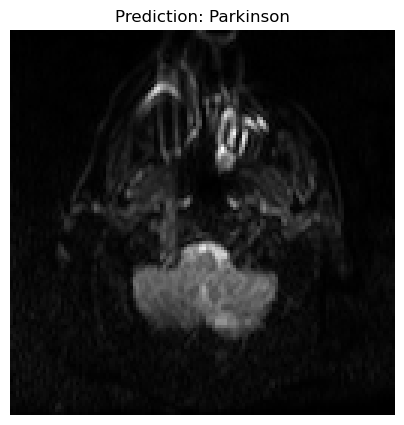

Result: Parkinson


In [3]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from skimage.transform import resize
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd

# 1. Define custom loss to load the feature extractor model
# This is required because your model was trained with a custom triplet loss.
def semi_hard_triplet_loss(labels, embeddings):
    return tf.reduce_mean(tf.square(embeddings))

# 2. Load the trained CNN and KNN models
# Note: Ensure these paths match where you saved your files.
model_path = './model_checkpoints/my_model.h5'
feature_extractor = load_model(
    model_path, 
    custom_objects={'semi_hard_triplet_loss': semi_hard_triplet_loss, 'tf': tf},
    safe_mode=False
)

# Load the data used to train the KNN to recreate the classifier
adi_path = 'pd_features'
labels_tr = np.array(pd.read_csv(os.path.join(adi_path, 'labels_AD1_CN0_train.csv'), index_col=0))
tr_feats = pd.read_csv(os.path.join(adi_path, 'feature_train.csv'), index_col=0)

# Re-initialize and fit the KNN (n_neighbors=7 as per your notebook)
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(tr_feats, labels_tr.ravel())

def predict_user_image():
    print("--- Parkinson's Detection System ---")
    img_path = input("Please enter the path to your image (e.g., test.png): ")

    if not os.path.exists(img_path):
        print(f"Error: The file '{img_path}' was not found.")
        return

    try:
        # 3. Load and Preprocess (matching training dimensions: 121x121)
        if img_path.lower().endswith('.npy'):
            img_arr = np.load(img_path, allow_pickle=True)
        else:
            img = image.load_img(img_path)
            img_arr = image.img_to_array(img)

        # Resize and normalize
        img_arr_resized = resize(img_arr, (121, 121)) / 255.0
        img_batch = np.expand_dims(img_arr_resized, axis=0)

        # 4. CNN Feature Extraction (64-dim embedding)
        prediction = feature_extractor.predict(img_batch, verbose=0)
        features = prediction[0].reshape(1, -1)

        # 5. KNN Classification
        result = knn.predict(features)
        probability = knn.predict_proba(features)

        # 6. Display Results
        # Mapping: 0 = Normal (CN), 1 = Parkinson
        classes = ['Normal', 'Parkinson']
        diagnosis = classes[result[0]]
        confidence = np.max(probability) * 100

        plt.figure(figsize=(5, 5))
        # Use original image for display
        display_img = image.load_img(img_path) if not img_path.endswith('.npy') else img_arr
        plt.imshow(display_img)
        plt.title(f"Prediction: {diagnosis}")
        plt.axis('off')
        plt.show()

        print(f"Result: {diagnosis}")
        #print(f"Confidence Level: {confidence:.2f}%")

    except Exception as e:
        print(f"An error occurred during processing: {e}")

# Start the detection system
predict_user_image()

In [8]:
import joblib
joblib.dump(model, "models/knn_model.pkl") # Assuming 'knn' is your trained model variable

['models/knn_model.pkl']

In [1]:
pip install streamlit tensorflow scikit-learn joblib pillow


In [2]:
pip install streamlit-authenticator


   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.3 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.3 MB ? eta -:--:--
   --------- ------------------------------ 0.5/2.3 MB 682.2 kB/s eta 0:00:03
   --------- ------------------------------ 0.5/2.3 MB 682.2 kB/s eta 0:00:03
   ------------- -------------------------- 0.8/2.3 MB 670.1 kB/s eta 0:00:03
   ------------------ --------------------- 1.0/2.3 MB 774.3 kB/s eta 0:00:02
   ----------------------- ---------------- 1.3/2.3 MB 914.2 kB/s eta 0:00:02
   --------------------------- ------------ 1.6/2.3 MB 900.2 kB/s eta 0:00:01
   -------------------------------- ------- 1.8/2.3 MB 929.8 kB/s eta 0:00:01
   -------------------------------- ------- 1.8/2.3 MB 929.8 kB/s eta 0:00:01
   ------------------------------------ --- 2.1/2.3 MB 854.3 kB/s eta 0:00:01
   -------------------

In [3]:
pip install plotly pandas streamlit-authenticator

Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install streamlit streamlit-authenticator pandas plotly tensorflow joblib pillow

Note: you may need to restart the kernel to use updated packages.
